## Required Imports

In [15]:
import os
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import torch
import torch.nn as nn
import torch.optim as optim

from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from tqdm.notebook import tqdm
from torchvision.datasets import MNIST  # using MNIST for simple demonstration
from sklearn.decomposition import PCA

## Data Transforms

In [16]:
transform = transforms.Compose(
    [
        transforms.Resize((32, 32)), # for MNIST dataset, we resize the image to 32x32 for convenience purpose
        transforms.ToTensor(), # convert the image to a tensor  
    ]
)

# load the MNIST dataset
train_dataset = MNIST(root='../../data', train=True, download=True, transform=transform)
test_dataset = MNIST(root='../../data', train=False, download=True, transform=transform)

## Set the Device

In [17]:
# define the device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

Using device: cuda


## Exploring the Data

In [18]:
for image, label in train_dataset:
    print('-'*100)
    print('Basic Image Stats:')
    print(f'Image shape: {image.shape}.')
    print(f'Label: {label}.')
    print(f'Image min: {image.min()}.')
    print(f'Image max: {image.max()}.')
    print('-'*100)
    print(f'Image pixels:\n {image}.')
    print('-'*100)
    break

----------------------------------------------------------------------------------------------------
Basic Image Stats:
Image shape: torch.Size([1, 32, 32]).
Label: 5.
Image min: 0.0.
Image max: 0.9921568632125854.
----------------------------------------------------------------------------------------------------
Image pixels:
 tensor([[[0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.],
         ...,
         [0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.]]]).
----------------------------------------------------------------------------------------------------


## The Vanilla Autoencoder

In [19]:
class Autoencoder(nn.Module):
    """A simple autoencoder model. The encoder network is a stack of linear layers with ReLU activation functions
    as nonlinearities. The autoencoder network is trained to learn a compressed representation of the data.
    """
    def __init__(self, bottleneck_size: int=2):
        super(Autoencoder, self).__init__()
        
        self.encoder = nn.Sequential(
            nn.Linear(32 * 32, 128),
            nn.ReLU(),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Linear(32, bottleneck_size)
        )
        
        self.decoder = nn.Sequential(
            nn.Linear(bottleneck_size, 32),
            nn.ReLU(),
            nn.Linear(32, 64),
            nn.ReLU(),
            nn.Linear(64, 128),
            nn.ReLU(),
            nn.Linear(128, 32 * 32),
            nn.Sigmoid() # ensure the output is in the range [0, 1] for visualization and reconstruction
                         # to ensure the output is in the range [-1, 1], we can use nn.Tanh() instead of nn.Sigmoid()
        )
    
    def encode(self, x):
        """Encoder function to encode the image to a latent space.
        """
        return self.encoder(x)
    
    def decode(self, x):
        """Decoder function to decode the latent space to an image.
        """
        x = self.decoder(x)
        x = x.reshape(-1, 1, 32, 32) # reshape the output to the original image shape
        return x
    
    def forward(self, x):
        b, c, h, w = x.shape

        x = x.flatten(start_dim=1) # flatten the image to a 1D vector starting from the second dimension

        encoded = self.encode(x) # encode the image to a latent space
        decoded = self.decode(encoded) # decode the latent space to an image

        return encoded, decoded

### A Simple Forward Pass

In [20]:
model = Autoencoder()
rand = torch.randn(2, 1, 32, 32)
model(rand)

(tensor([[-0.1300, -0.1214],
         [-0.1529, -0.0420]], grad_fn=<AddmmBackward0>),
 tensor([[[[0.4969, 0.5044, 0.5339,  ..., 0.5026, 0.4931, 0.4680],
           [0.5113, 0.4786, 0.5072,  ..., 0.5039, 0.5141, 0.5116],
           [0.5037, 0.4522, 0.5241,  ..., 0.4708, 0.5131, 0.5020],
           ...,
           [0.5075, 0.4870, 0.4854,  ..., 0.4527, 0.4970, 0.5078],
           [0.5043, 0.5286, 0.4869,  ..., 0.4942, 0.4968, 0.4908],
           [0.4917, 0.4830, 0.5128,  ..., 0.4934, 0.5154, 0.4925]]],
 
 
         [[[0.4965, 0.5046, 0.5339,  ..., 0.5028, 0.4925, 0.4678],
           [0.5107, 0.4789, 0.5075,  ..., 0.5045, 0.5143, 0.5116],
           [0.5044, 0.4531, 0.5246,  ..., 0.4707, 0.5137, 0.5010],
           ...,
           [0.5073, 0.4862, 0.4862,  ..., 0.4521, 0.4972, 0.5078],
           [0.5046, 0.5279, 0.4882,  ..., 0.4933, 0.4972, 0.4914],
           [0.4910, 0.4833, 0.5128,  ..., 0.4924, 0.5152, 0.4922]]]],
        grad_fn=<ViewBackward0>))

## Training

In [21]:
def train(
    model: nn.Module,
    train_dataset: Dataset,
    test_dataset: Dataset,
    batch_size: int,
    training_iterations: int,
    eval_iterations: int
    ):

        print("Training the model...")
        print(model)

        model  = model.to(device)

        train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
        test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

        optimizer = optim.Adam(model.parameters(), lr=0.0005)

        train_loss = []
        eval_loss = []
        train_losses = []
        eval_losses = []

        encoded_data_per_eval = []

        pbar = tqdm(range(training_iterations), desc="Training")
        last_eval_loss = None

        train = True

        global_step = 0

        while train:
            model.train()
            for images, labels in train_loader:
                images = images.to(device)

                optimizer.zero_grad()
                
                encoded, recon = model(images)

                loss = torch.mean((images - recon) ** 2) # compute the mean squared error
                train_loss.append(loss.item())

                loss.backward()
                optimizer.step()

                if global_step % eval_iterations == 0:
                    model.eval()
                    encoded_evals = []

                    for images, labels in test_loader:

                        with torch.no_grad():
                            images = images.to(device)
                        
                        encoded, recon = model(images)

                        loss = torch.mean((images - recon) ** 2)
                        eval_loss.append(loss.item())

                        # store the encoded data and the labels
                        encoded, labels = encoded.cpu().flatten(1), labels.reshape(-1, 1)
                        encoded_evals.append(torch.cat((encoded, labels), axis=-1))
                    
                    encoded_data_per_eval.append(torch.concatenate(encoded_evals).detach())
                    
                    train_loss = np.mean(train_loss)
                    eval_loss = np.mean(eval_loss)
                    last_eval_loss = eval_loss
                    
                    train_losses.append(train_loss)
                    eval_losses.append(eval_loss)

                    print(f'training loss: {train_loss:.4f}, eval loss: {eval_loss:.4f}')
                    
                    # reset the loss values for the next evaluation
                    train_loss = []
                    eval_loss = []
                
                global_step += 1
                pbar.update(1)

                if global_step >= training_iterations:
                    print("Training complete.")
                    train = False
                    break
        
        # store the encoded data as numpy arrays for each evaluation
        encoded_data_per_eval = [i.numpy() for i in encoded_data_per_eval]  # convert tensors to numpy (avoids np.array deprecation with PyTorch)

        return model, train_losses, eval_losses, encoded_data_per_eval

In [22]:
# start with a fresh model
model = Autoencoder(bottleneck_size=2)

In [23]:
model, train_losses, eval_losses, encoded_data_per_eval = train(
    model,
    train_dataset,
    test_dataset,
    batch_size=64,
    training_iterations=5000,
    eval_iterations=250)

Training the model...
Autoencoder(
  (encoder): Sequential(
    (0): Linear(in_features=1024, out_features=128, bias=True)
    (1): ReLU()
    (2): Linear(in_features=128, out_features=64, bias=True)
    (3): ReLU()
    (4): Linear(in_features=64, out_features=32, bias=True)
    (5): ReLU()
    (6): Linear(in_features=32, out_features=2, bias=True)
  )
  (decoder): Sequential(
    (0): Linear(in_features=2, out_features=32, bias=True)
    (1): ReLU()
    (2): Linear(in_features=32, out_features=64, bias=True)
    (3): ReLU()
    (4): Linear(in_features=64, out_features=128, bias=True)
    (5): ReLU()
    (6): Linear(in_features=128, out_features=1024, bias=True)
    (7): Sigmoid()
  )
)


Training:   0%|          | 0/5000 [00:00<?, ?it/s]

training loss: 0.2223, eval loss: 0.2201
training loss: 0.0776, eval loss: 0.0552
training loss: 0.0530, eval loss: 0.0517
training loss: 0.0486, eval loss: 0.0462
training loss: 0.0445, eval loss: 0.0432
training loss: 0.0419, eval loss: 0.0407
training loss: 0.0399, eval loss: 0.0393
training loss: 0.0388, eval loss: 0.0383
training loss: 0.0379, eval loss: 0.0377
training loss: 0.0373, eval loss: 0.0371
training loss: 0.0367, eval loss: 0.0368
training loss: 0.0365, eval loss: 0.0364
training loss: 0.0361, eval loss: 0.0359
training loss: 0.0357, eval loss: 0.0358
training loss: 0.0355, eval loss: 0.0355
training loss: 0.0351, eval loss: 0.0352
training loss: 0.0347, eval loss: 0.0348
training loss: 0.0346, eval loss: 0.0347
training loss: 0.0346, eval loss: 0.0346
training loss: 0.0343, eval loss: 0.0344
Training complete.


## Plot the Embedding Space through Training

Now we can write a function that takes in the `encoded_data_per_eval` from the training output, and create an animation of the embedding space to see how the neural network learns. Note that the first two columns of the `encoded_data_per_eval` denote the principal component axes where the model decides to place the embeddings, and the last column denotes the corresponding class labels of the embeddings.

In [24]:
print(encoded_data_per_eval[0])

[[ 0.05962756 -0.21621117  7.        ]
 [ 0.06693271 -0.21134418  2.        ]
 [ 0.06043023 -0.21487972  1.        ]
 ...
 [ 0.06781538 -0.20209594  4.        ]
 [ 0.06766624 -0.21253711  5.        ]
 [ 0.07986601 -0.20495667  6.        ]]


In [25]:
from matplotlib.animation import FuncAnimation, PillowWriter

def generate_embedding_animation(
    encodings: np.ndarray | list[np.ndarray],
    title: str = "Autoencoder Embedding Space",
    *,
    output_path: str | None = None,
    eval_iterations: int = 250,
    fps: int = 4,
):
    """
    Generate a static plot or GIF of the embedding space.
    Pass a single array for a static plot, or a list of arrays for a GIF.
    """
    def _plot_frame(ax, data: np.ndarray, frame_title: str, x_lim=None, y_lim=None):
        df = pd.DataFrame(data, columns=["x", "y", "class"])
        df = df.sort_values(by="class")
        df["class"] = df["class"].astype(int).astype(str)
        for label, coordinates in df.groupby("class"):
            ax.scatter(x=coordinates["x"], y=coordinates["y"], label=label, alpha=0.8, s=5)
        ax.set_title(frame_title)
        ax.set_xlabel("x")
        ax.set_ylabel("y")
        if x_lim is not None:
            ax.set_xlim(x_lim)
        if y_lim is not None:
            ax.set_ylim(y_lim)
        ax.legend()

    if isinstance(encodings, np.ndarray):
        # Single frame - static plot
        fig, ax = plt.subplots(figsize=(8, 6))
        _plot_frame(ax, encodings, title)
        plt.show()
    else:
        # List of frames - GIF
        path = output_path or "embedding_progression.gif"
        all_x = np.concatenate([d[:, 0] for d in encodings])
        all_y = np.concatenate([d[:, 1] for d in encodings])
        x_margin = (all_x.max() - all_x.min()) * 0.05 or 0.1
        y_margin = (all_y.max() - all_y.min()) * 0.05 or 0.1
        x_lim = (all_x.min() - x_margin, all_x.max() + x_margin)
        y_lim = (all_y.min() - y_margin, all_y.max() + y_margin)

        fig, ax = plt.subplots(figsize=(8, 6))

        def update(frame_idx: int):
            ax.clear()
            step = (frame_idx + 1) * eval_iterations
            _plot_frame(ax, encodings[frame_idx], f"Embedding Space at Step {step}", x_lim, y_lim)

        anim = FuncAnimation(fig, update, frames=len(encodings), interval=1000 // fps)
        anim.save(path, writer=PillowWriter(fps=fps))
        plt.close()
        print(f"GIF saved to {path}")

In [26]:
# Generate GIF of training progression
generate_embedding_animation(
    encoded_data_per_eval,
    output_path="embedding_progression.gif",
    eval_iterations=250,
)

GIF saved to embedding_progression.gif


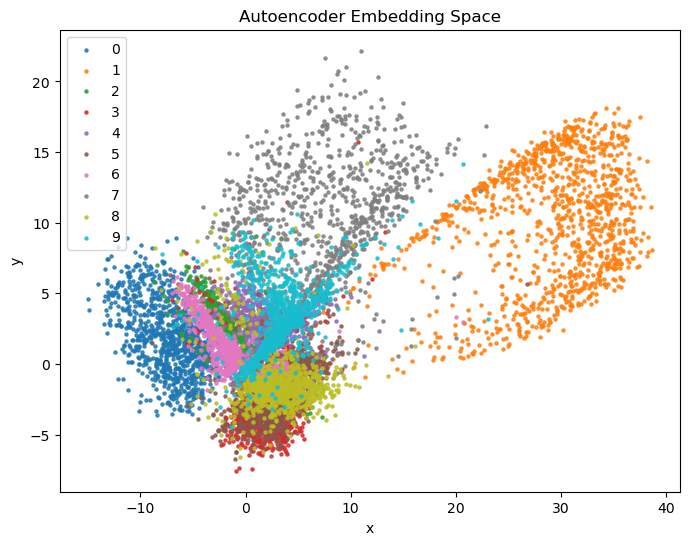

In [27]:
generate_embedding_animation(encoded_data_per_eval[-1], "Autoencoder Embedding Space")

The above plot demonstrates the compressed latent space of the model. If we take a look at the plot and the corresponding labels, we can see some effects of clustering here, for instance, the points representing "4"(purple) and "9" (blue) are very close to each other, coincide with their visual appearances.

Now let's see the progression.

![Embedding progression](embedding_progression.gif)